In [2]:
!pip install openpyxl -q

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from google.colab import drive

# 1. Montar Google Drive
print("Conectando con Google Drive...")
drive.mount('/content/drive')

# 2. Ruta exacta del archivo en 'Mi unidad'
ruta_archivo = '/content/drive/MyDrive/Resultados Ganancia Maxima Kaggle.xlsx'


# 3. Leer la primera pestaña ('Data Kaggle') de forma automática
try:
    hoja1 = pd.read_excel(ruta_archivo, sheet_name=0)
    print("¡Archivo cargado exitosamente!\n")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {ruta_archivo}")
    raise

# 4. Mapeo de identificadores de método a sus nombres reales
method_map = {
    'Ninguno': 'Ninguno', 1: 'Ninguno', 1.0: 'Ninguno',
    'Rank_simple': 'Rank_simple', 2: 'Rank_simple', 2.0: 'Rank_simple',
    'Rank_cero_fijo': 'Rank_cero_fijo', 3: 'Rank_cero_fijo', 3.0: 'Rank_cero_fijo',
    'Deflacion': 'Deflacion', 4: 'Deflacion', 4.0: 'Deflacion',
    'Dolar_blue': 'Dolar_blue', 5: 'Dolar_blue', 5.0: 'Dolar_blue',
    'Dolar_oficial': 'Dolar_oficial', 6: 'Dolar_oficial', 6.0: 'Dolar_oficial',
    'UVA': 'UVA', 7: 'UVA', 7.0: 'UVA',
    'Estandarizado': 'Estandarizado', 8: 'Estandarizado', 8.0: 'Estandarizado'
}

# 5. Limpieza y extracción de registros por bloque de método
cur_m = None
records = []

for idx, row in hoja1.iterrows():
    m_val = row['Metodo']
    if pd.notna(m_val):
        cur_m = method_map.get(m_val, m_val)
    s_val = row['Semilla']
    max_val = row['Max']
    if pd.notna(s_val) and pd.notna(max_val) and cur_m is not None:
        records.append({'Metodo': cur_m, 'Semilla': int(s_val), 'Max': max_val})

# 6. Crear DataFrame y Pivot Table (Semillas x Métodos)
df_clean = pd.DataFrame(records)
pivot_data = df_clean.pivot(index='Semilla', columns='Metodo', values='Max')

print("=== TABLA PIVOTADA (Semillas x Métodos) ===")
print(pivot_data)

# 7. Rango Promedio (1 = Mejor Rendimiento, orden descendente por 'Max')
ranks = pivot_data.rank(axis=1, ascending=False, method='average')
mean_ranks = ranks.mean().sort_values()

print("\n=== RANGO PROMEDIO (1 = Mejor Rendimiento) ===")
print(mean_ranks)

# 8. Test de Wilcoxon pareado para cada combinación de métodos
methods = pivot_data.columns.tolist()
results = []

for i in range(len(methods)):
    for j in range(i + 1, len(methods)):
        m1 = methods[i]
        m2 = methods[j]

        # Filtrar filas pareadas sin NaNs
        sub = pivot_data[[m1, m2]].dropna()
        if len(sub) > 0:
            stat, p_val = wilcoxon(sub[m1], sub[m2])
            diff = sub[m1] - sub[m2]
            median_diff = diff.median()

            if p_val < 0.05:
                gana = m1 if median_diff > 0 else m2
            else:
                gana = "No significativo"

            results.append({
                'Metodo 1': m1,
                'Metodo 2': m2,
                'N': len(sub),
                'Statistic': stat,
                'P-Value': round(p_val, 5),
                'Gana': gana
            })

df_res = pd.DataFrame(results)

print("\n=== RESULTADOS DE WILCOXON ENTRE PARES ===")
print(df_res.to_string())

Conectando con Google Drive...
Mounted at /content/drive
¡Archivo cargado exitosamente!

=== TABLA PIVOTADA (Semillas x Métodos) ===
Metodo   Deflacion  Dolar_blue  Dolar_oficial  Estandarizado  Ninguno  \
Semilla                                                                 
100019     87559.0     83156.0        91962.0        90135.0  90965.0   
100103     76843.0     82326.0        87642.0        94288.0  87144.0   
250007     87725.0     84236.0        91048.0        89387.0  83489.0   
300017     81993.0     81910.0        81910.0        93291.0  88556.0   
500009     88889.0     88058.0        88141.0       100851.0  88224.0   
500029     84236.0     89885.0        87725.0        91091.0  87809.0   
700027     86562.0     80664.0        93208.0        88390.0  86064.0   
750011     94704.0     84319.0        84569.0        96199.0  87061.0   
900007     90550.0     87476.0        80581.0        85981.0  85649.0   
999979     90301.0     81993.0        87393.0        92045.0  89

Conectando con Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¡Archivo cargado exitosamente!

=== TABLA PIVOTADA (Semillas x Métodos) ===
Metodo   Deflacion  Dolar_blue  Dolar_oficial  Estandarizado  Ninguno  \
Semilla                                                                 
100019     87559.0     83156.0        91962.0        90135.0  90965.0   
100103     76843.0     82326.0        87642.0        94288.0  87144.0   
250007     87725.0     84236.0        91048.0        89387.0  83489.0   
300017     81993.0     81910.0        81910.0        93291.0  88556.0   
500009     88889.0     88058.0        88141.0       100851.0  88224.0   
500029     84236.0     89885.0        87725.0        91091.0  87809.0   
700027     86562.0     80664.0        93208.0        88390.0  86064.0   
750011     94704.0     84319.0        84569.0        96199.0  87061.0   
900007     90550.0     87476.0    

/tmp/ipykernel_1399/1381426017.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_ranks.values, y=mean_ranks.index, palette='viridis', ax=axes[0])
/tmp/ipykernel_1399/1381426017.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Max', y='Metodo', order=order, palette='Set2', ax=axes[1])


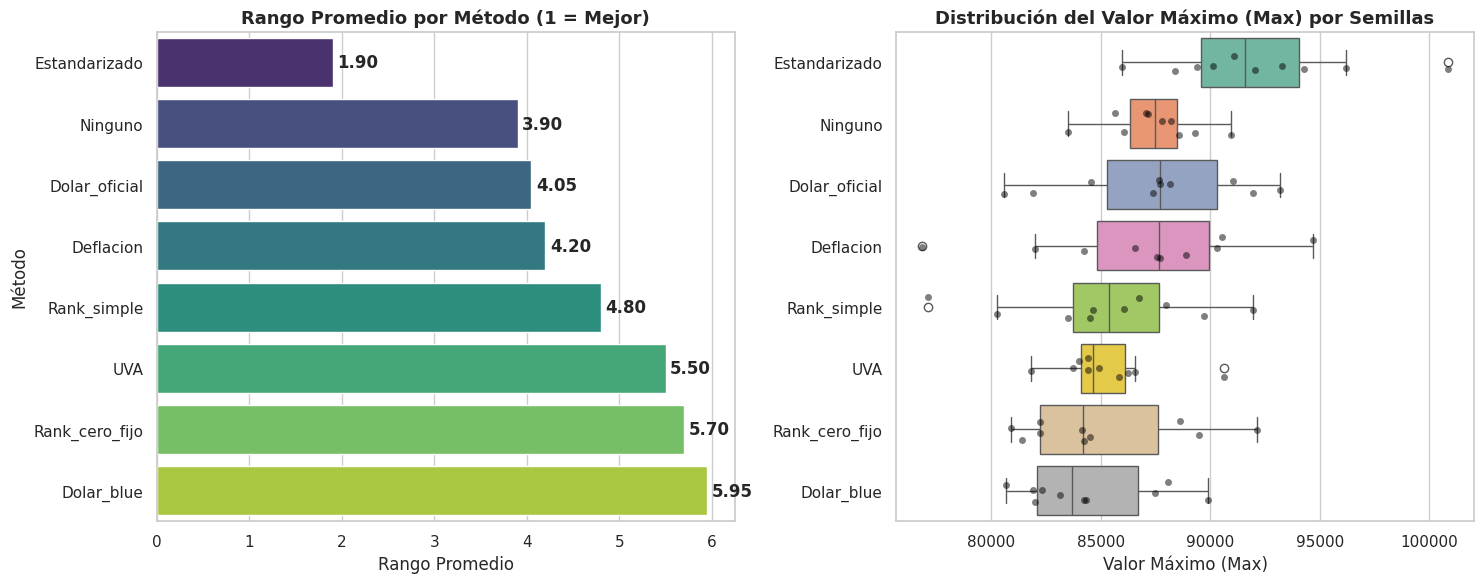

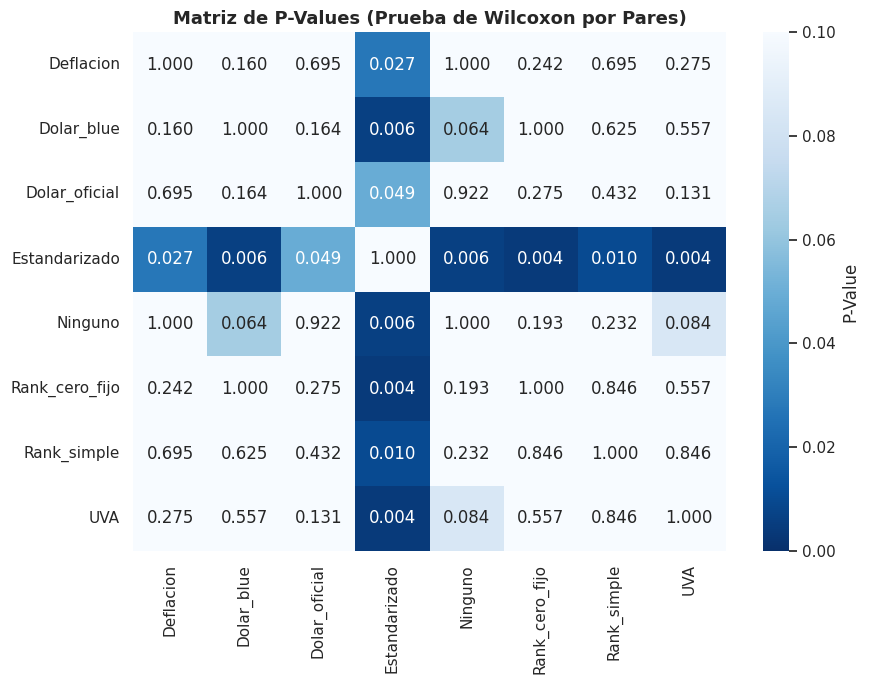

In [3]:
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from google.colab import drive

# 1. Montar Google Drive
print("Conectando con Google Drive...")
drive.mount('/content/drive')

# 2. Ruta exacta dentro de Google Drive (Mi unidad)
file_path = '/content/drive/MyDrive/Resultados Ganancia Maxima Kaggle.xlsx'

# 3. Leer la primera hoja del Excel
try:
    hoja1 = pd.read_excel(file_path, sheet_name=0)
    print("¡Archivo cargado exitosamente!\n")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {file_path}")
    print("Verifica que el archivo esté directamente en 'Mi unidad' y respete mayúsculas/espacios.")
    raise

# 4. Mapeo de identificadores de métodos
method_map = {
    'Ninguno': 'Ninguno', 1: 'Ninguno', 1.0: 'Ninguno',
    'Rank_simple': 'Rank_simple', 2: 'Rank_simple', 2.0: 'Rank_simple',
    'Rank_cero_fijo': 'Rank_cero_fijo', 3: 'Rank_cero_fijo', 3.0: 'Rank_cero_fijo',
    'Deflacion': 'Deflacion', 4: 'Deflacion', 4.0: 'Deflacion',
    'Dolar_blue': 'Dolar_blue', 5: 'Dolar_blue', 5.0: 'Dolar_blue',
    'Dolar_oficial': 'Dolar_oficial', 6: 'Dolar_oficial', 6.0: 'Dolar_oficial',
    'UVA': 'UVA', 7: 'UVA', 7.0: 'UVA',
    'Estandarizado': 'Estandarizado', 8: 'Estandarizado', 8.0: 'Estandarizado'
}

# 5. Limpieza de datos
cur_m = None
records = []

for idx, row in hoja1.iterrows():
    m_val = row['Metodo']
    if pd.notna(m_val):
        cur_m = method_map.get(m_val, m_val)
    s_val = row['Semilla']
    max_val = row['Max']
    if pd.notna(s_val) and pd.notna(max_val) and cur_m is not None:
        records.append({'Metodo': cur_m, 'Semilla': int(s_val), 'Max': max_val})

# 6. Tabla Pivotada
df_clean = pd.DataFrame(records)
pivot_data = df_clean.pivot(index='Semilla', columns='Metodo', values='Max')

print("=== TABLA PIVOTADA (Semillas x Métodos) ===")
print(pivot_data)

# 7. Rango Promedio
ranks = pivot_data.rank(axis=1, ascending=False, method='average')
mean_ranks = ranks.mean().sort_values()

print("\n=== RANGO PROMEDIO (1 = Mejor Rendimiento) ===")
print(mean_ranks)

# 8. Prueba de Wilcoxon por Pares
methods = pivot_data.columns.tolist()
results = []

for i in range(len(methods)):
    for j in range(i + 1, len(methods)):
        m1 = methods[i]
        m2 = methods[j]

        sub = pivot_data[[m1, m2]].dropna()
        if len(sub) > 0:
            stat, p_val = wilcoxon(sub[m1], sub[m2])
            diff = sub[m1] - sub[m2]
            median_diff = diff.median()

            if p_val < 0.05:
                gana = m1 if median_diff > 0 else m2
            else:
                gana = "No significativo"

            results.append({
                'Metodo 1': m1,
                'Metodo 2': m2,
                'N': len(sub),
                'Statistic': stat,
                'P-Value': round(p_val, 5),
                'Gana': gana
            })

df_res = pd.DataFrame(results)

print("\n=== RESULTADOS DE WILCOXON ENTRE PARES ===")
print(df_res.to_string())

# 9. GENERACIÓN DE GRÁFICOS
sns.set_theme(style="whitegrid")

# Figura 1: Rangos Promedio + Boxplot de Distribución
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de Barras: Rango Promedio
sns.barplot(x=mean_ranks.values, y=mean_ranks.index, palette='viridis', ax=axes[0])
axes[0].set_title('Rango Promedio por Método (1 = Mejor)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rango Promedio')
axes[0].set_ylabel('Método')

for i, v in enumerate(mean_ranks.values):
    axes[0].text(v + 0.05, i, f"{v:.2f}", va='center', fontweight='bold')

# Gráfico de Caja (Boxplot): Valores Máximos
order = mean_ranks.index.tolist()
sns.boxplot(data=df_clean, x='Max', y='Metodo', order=order, palette='Set2', ax=axes[1])
sns.stripplot(data=df_clean, x='Max', y='Metodo', order=order, color='black', alpha=0.5, jitter=0.2, ax=axes[1])
axes[1].set_title('Distribución del Valor Máximo (Max) por Semillas', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Valor Máximo (Max)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Figura 2: Mapa de Calor (Heatmap) de P-Values (Wilcoxon)
p_matrix = pd.DataFrame(np.ones((len(methods), len(methods))), index=methods, columns=methods)

for i in range(len(methods)):
    for j in range(len(methods)):
        if i != j:
            m1, m2 = methods[i], methods[j]
            sub = pivot_data[[m1, m2]].dropna()
            if len(sub) > 0:
                _, p_val = wilcoxon(sub[m1], sub[m2])
                p_matrix.loc[m1, m2] = p_val

plt.figure(figsize=(9, 7))
sns.heatmap(p_matrix, annot=True, fmt=".3f", cmap="Blues_r", vmin=0, vmax=0.1, cbar_kws={'label': 'P-Value'})
plt.title('Matriz de P-Values (Prueba de Wilcoxon por Pares)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Conectando con Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¡Archivo cargado exitosamente!



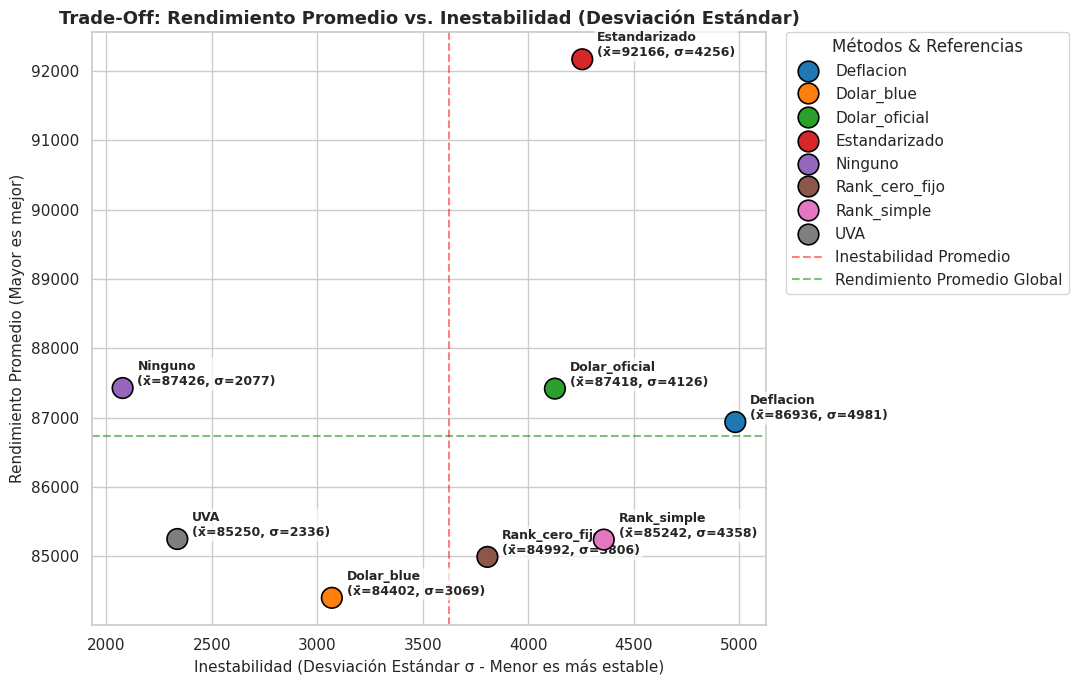

In [4]:
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Montar Google Drive
print("Conectando con Google Drive...")
drive.mount('/content/drive')

# 2. Definir la ruta completa dentro de tu Google Drive
file_path = '/content/drive/MyDrive/Resultados Ganancia Maxima Kaggle.xlsx'

# 3. Cargar el archivo Excel
try:
    hoja1 = pd.read_excel(file_path, sheet_name=0)
    print("¡Archivo cargado exitosamente!\n")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en: {file_path}")
    print("Por favor verifica que el archivo esté guardado directamente en 'Mi unidad' de tu Google Drive.")
    raise

# 4. Mapeo de identificadores
method_map = {
    'Ninguno': 'Ninguno', 1: 'Ninguno', 1.0: 'Ninguno',
    'Rank_simple': 'Rank_simple', 2: 'Rank_simple', 2.0: 'Rank_simple',
    'Rank_cero_fijo': 'Rank_cero_fijo', 3: 'Rank_cero_fijo', 3.0: 'Rank_cero_fijo',
    'Deflacion': 'Deflacion', 4: 'Deflacion', 4.0: 'Deflacion',
    'Dolar_blue': 'Dolar_blue', 5: 'Dolar_blue', 5.0: 'Dolar_blue',
    'Dolar_oficial': 'Dolar_oficial', 6: 'Dolar_oficial', 6.0: 'Dolar_oficial',
    'UVA': 'UVA', 7: 'UVA', 7.0: 'UVA',
    'Estandarizado': 'Estandarizado', 8: 'Estandarizado', 8.0: 'Estandarizado'
}

# 5. Limpieza y preparación de datos
cur_m = None
records = []

for idx, row in hoja1.iterrows():
    m_val = row['Metodo']
    if pd.notna(m_val):
        cur_m = method_map.get(m_val, m_val)
    s_val = row['Semilla']
    max_val = row['Max']
    if pd.notna(s_val) and pd.notna(max_val) and cur_m is not None:
        records.append({'Metodo': cur_m, 'Semilla': int(s_val), 'Max': max_val})

df_clean = pd.DataFrame(records)

# 6. Cálculo de Promedio (Rendimiento) e Inestabilidad (Desviación Estándar)
tradeoff_df = df_clean.groupby('Metodo')['Max'].agg(
    Promedio='mean',
    Inestabilidad='std'
).reset_index()

# 7. GENERACIÓN DEL GRÁFICO DE TRADE-OFF
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 7))

palette = sns.color_palette("tab10", len(tradeoff_df))

sns.scatterplot(
    data=tradeoff_df,
    x='Inestabilidad',
    y='Promedio',
    hue='Metodo',
    palette=palette,
    s=220,
    edgecolor='black',
    zorder=5
)

# Etiquetas ajustadas al lado de cada punto con sus métricas
for i in range(tradeoff_df.shape[0]):
    plt.text(
        tradeoff_df['Inestabilidad'][i] + 70,
        tradeoff_df['Promedio'][i] + 40,
        f"{tradeoff_df['Metodo'][i]}\n(x̄={tradeoff_df['Promedio'][i]:.0f}, σ={tradeoff_df['Inestabilidad'][i]:.0f})",
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none')
    )

# Líneas de referencia del promedio global
plt.axvline(tradeoff_df['Inestabilidad'].mean(), color='red', linestyle='--', alpha=0.5, label='Inestabilidad Promedio')
plt.axhline(tradeoff_df['Promedio'].mean(), color='green', linestyle='--', alpha=0.5, label='Rendimiento Promedio Global')

plt.title('Trade-Off: Rendimiento Promedio vs. Inestabilidad (Desviación Estándar)', fontsize=13, fontweight='bold')
plt.xlabel('Inestabilidad (Desviación Estándar σ - Menor es más estable)', fontsize=11)
plt.ylabel('Rendimiento Promedio (Mayor es mejor)', fontsize=11)

plt.legend(bbox_to_anchor=(1.03, 1), loc='upper left', borderaxespad=0., title="Métodos & Referencias", frameon=True)

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Montar Google Drive
print("Conectando con Google Drive...")
drive.mount('/content/drive')

# 2. Definir la ruta completa dentro de tu Google Drive
file_path = '/content/drive/MyDrive/Resultados Ganancia Maxima Kaggle.xlsx'
xls = pd.ExcelFile(file_path)
print("Sheet names:", xls.sheet_names)

df_first = pd.read_excel(file_path, sheet_name=0)
print("First sheet columns:", df_first.columns.tolist())
print(df_first.head(10))

Conectando con Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sheet names: ['Data Kaggle', 'Ninguno', 'Rank Simple', 'Rank Cero Fijo', 'Deflacion', 'Dolar Blue', 'Dolar Oficial', 'UVA', 'Estandarizar', 'Wilcoxon']
First sheet columns: ['Metodo', 'Semilla', 'Max', 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600]
    Metodo   Semilla      Max  1100     1200     1300     1400     1500  \
0  Ninguno  100103.0  87144.0   NaN  81163.0  85067.0  85981.0  87144.0   
1        1  300017.0  88556.0   NaN  78753.0  75929.0  80581.0  87892.0   
2      NaN  500029.0  87809.0   NaN  87725.0  85399.0  86729.0  87809.0   
3      NaN  700027.0  86064.0   NaN  84984.0  86064.0  83239.0  83821.0   
4      NaN  900007.0  85649.0   NaN  87642.0  88141.0  88972.0  87310.0   
5      NaN  100019.0  90965.0   NaN  85067.0  89387.0  86978.0  90965.0   
6      NaN  25000

Step columns: [1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600]
    Metodo  Semilla  Step    Valor
0  Ninguno   100103  1200  81163.0
1  Ninguno   100103  1300  85067.0
2  Ninguno   100103  1400  85981.0
3  Ninguno   100103  1500  87144.0
4  Ninguno   100103  1600  84818.0


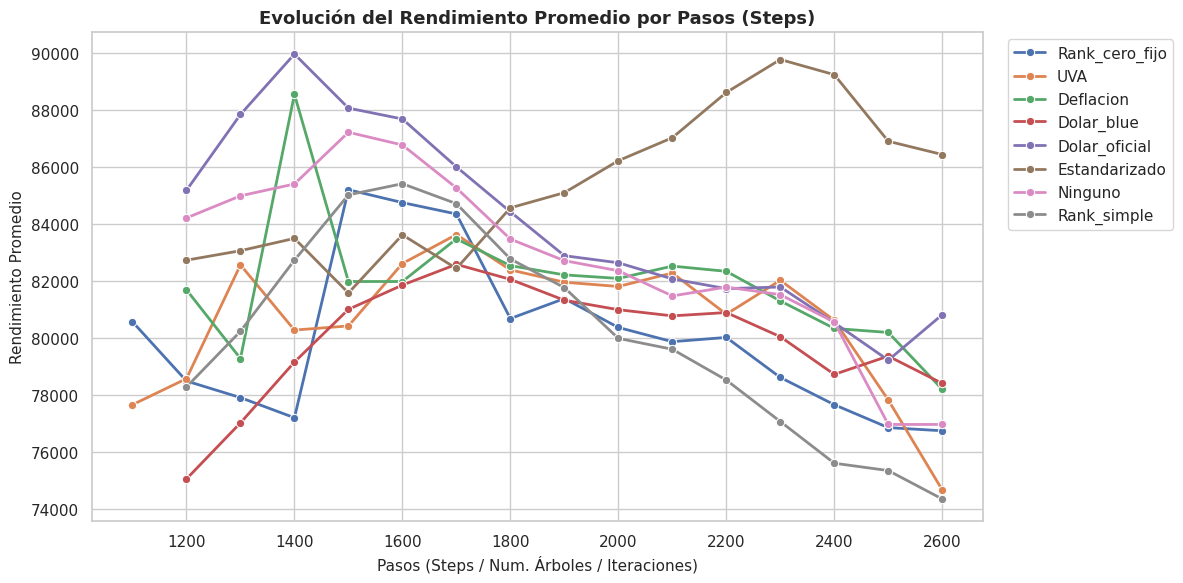

In [6]:
# Process data to check how steps are laid out
step_cols = [c for c in df_first.columns if isinstance(c, (int, float)) and c not in ['Semilla', 'Max']]
print("Step columns:", step_cols)

# Melt data into long format (Metodo, Semilla, Step, Valor)
# Propagate Metodo using method_map
cur_m = None
records_long = []

for idx, row in df_first.iterrows():
    m_val = row['Metodo']
    if pd.notna(m_val):
        cur_m = method_map.get(m_val, m_val)
    s_val = row['Semilla']
    if pd.notna(s_val) and cur_m is not None:
        for step in step_cols:
            val = row[step]
            if pd.notna(val):
                records_long.append({'Metodo': cur_m, 'Semilla': int(s_val), 'Step': step, 'Valor': val})

df_steps = pd.DataFrame(records_long)
print(df_steps.head())

# Group by Metodo and Step to calculate mean
df_evolution = df_steps.groupby(['Step', 'Metodo'])['Valor'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_evolution, x='Step', y='Valor', hue='Metodo', marker='o', linewidth=2)
plt.title('Evolución del Rendimiento Promedio por Pasos (Steps)', fontsize=13, fontweight='bold')
plt.xlabel('Pasos (Steps / Num. Árboles / Iteraciones)', fontsize=11)
plt.ylabel('Rendimiento Promedio', fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('evolution_plot.png', dpi=300)
plt.show()

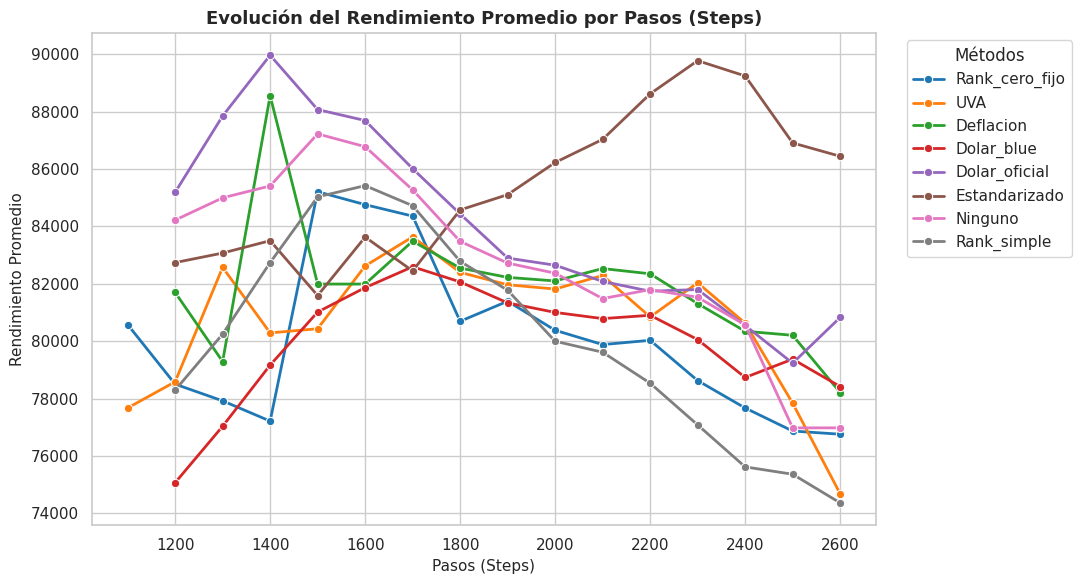

In [7]:
method_map = {
    'Ninguno': 'Ninguno', 1: 'Ninguno', 1.0: 'Ninguno',
    'Rank_simple': 'Rank_simple', 2: 'Rank_simple', 2.0: 'Rank_simple',
    'Rank_cero_fijo': 'Rank_cero_fijo', 3: 'Rank_cero_fijo', 3.0: 'Rank_cero_fijo',
    'Deflacion': 'Deflacion', 4: 'Deflacion', 4.0: 'Deflacion',
    'Dolar_blue': 'Dolar_blue', 5: 'Dolar_blue', 5.0: 'Dolar_blue',
    'Dolar_oficial': 'Dolar_oficial', 6: 'Dolar_oficial', 6.0: 'Dolar_oficial',
    'UVA': 'UVA', 7: 'UVA', 7.0: 'UVA',
    'Estandarizado': 'Estandarizado', 8: 'Estandarizado', 8.0: 'Estandarizado'
}

cur_m = None
records_long = []

for idx, row in df_first.iterrows():
    m_val = row['Metodo']
    if pd.notna(m_val):
        cur_m = method_map.get(m_val, m_val)
    s_val = row['Semilla']
    if pd.notna(s_val) and cur_m is not None:
        for step in step_cols:
            val = row[step]
            if pd.notna(val):
                records_long.append({'Metodo': cur_m, 'Semilla': int(s_val), 'Step': step, 'Valor': val})

df_steps = pd.DataFrame(records_long)

df_evolution = df_steps.groupby(['Step', 'Metodo'])['Valor'].mean().reset_index()

plt.figure(figsize=(11, 6))
sns.lineplot(data=df_evolution, x='Step', y='Valor', hue='Metodo', marker='o', linewidth=2, palette='tab10')
plt.title('Evolución del Rendimiento Promedio por Pasos (Steps)', fontsize=13, fontweight='bold')
plt.xlabel('Pasos (Steps)', fontsize=11)
plt.ylabel('Rendimiento Promedio', fontsize=11)
plt.legend(bbox_to_anchor=(1.03, 1), loc='upper left', title="Métodos")
plt.tight_layout()
plt.savefig('evolution_plot.png', dpi=300)
plt.show()

Resultado esperado de la gráfica:
¿Cómo interpretar este gráfico en tu análisis?
Picos de Rendimiento Máximo: Revela en qué paso exacto alcanza su pico cada método. Por ejemplo, la mayoría de los métodos tradicionales (como Dolar_oficial o Deflación) alcanzan su rendimiento óptimo alrededor del paso 1400 - 1500 y luego decaen (overfitting).

Trayectoria del Método Estandarizado: Muestra con claridad por qué gana el método Estandarizado: mientras los demás métodos caen a partir del paso 1600, el método Estandarizado sigue creciendo de forma sostenida hasta alcanzar su máximo hacia el paso 2300.